# 02 — Baselines com MLflow
**TC1: Rede Neural para Previsão de Churn — FIAP Pós-Tech MLOps**

**Pré-requisito:** rodar `01_eda.ipynb` para gerar `data/processed/telco_treated.csv`

Este notebook cobre:
- Pipeline de pré-processamento sklearn
- Split estratificado treino/teste
- DummyClassifier e LogisticRegression com validação cruzada
- Registro completo no MLflow
- Curvas ROC, PR e matriz de confusão

---

## 0. Setup

In [1]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)

from src.evaluation.metrics import compute_metrics

SEED = 42
np.random.seed(SEED)
COLORS = {'no_churn': '#4C72B0', 'churn': '#DD8452'}
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (11, 5)})

print('✅ Setup concluído | Seed:', SEED)

✅ Setup concluído | Seed: 42


---
## 1. Carregar dataset tratado

In [2]:
df = pd.read_csv('../data/processed/telco_treated.csv')
print(f'Shape: {df.shape}')
print(f'Churn rate: {df["Churn_bin"].mean()*100:.1f}%')
df.head(3)

Shape: (7043, 23)
Churn rate: 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_bin,tenure_bin
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0–6m
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,24–36m
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0–6m


---
## 2. Preparação — Features, Split e Pipeline

In [3]:
DROP_COLS = ['customerID', 'Churn', 'Churn_bin', 'tenure_bin']
NUMERIC_FEATURES = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATEGORICAL_FEATURES = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# Remove colunas que podem não existir no CSV tratado
drop_existing = [c for c in DROP_COLS if c in df.columns]
X = df.drop(columns=drop_existing)
y = df['Churn_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Treino: {X_train.shape[0]:,} | churn: {y_train.mean()*100:.1f}%')
print(f'Teste:  {X_test.shape[0]:,}  | churn: {y_test.mean()*100:.1f}%')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUMERIC_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
    ],
    remainder='drop'
)
print('\n✅ Pipeline de pré-processamento criado.')

Treino: 5,634 | churn: 26.5%
Teste:  1,409  | churn: 26.5%

✅ Pipeline de pré-processamento criado.


---
## 3. Baselines com MLflow

In [4]:
mlflow.set_experiment('churn-etapa1-baselines')
CV_FOLDS = 5
results = []
print('MLflow configurado. Experimento: churn-etapa1-baselines')

MLflow configurado. Experimento: churn-etapa1-baselines


In [5]:
# ── DummyClassifier ────────────────────────────────────────────────────────
with mlflow.start_run(run_name='DummyClassifier'):
    dummy = Pipeline([
        ('pre', preprocessor),
        ('clf', DummyClassifier(strategy='stratified', random_state=SEED))
    ])
    mlflow.log_params({
        'model': 'DummyClassifier', 'strategy': 'stratified', 'seed': SEED,
        'dataset_version': 'telco_treated.csv',
        'n_train': len(X_train), 'n_test': len(X_test),
        'churn_rate_train': round(y_train.mean(), 4), 'cv_folds': CV_FOLDS
    })
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    cv_res = cross_validate(dummy, X_train, y_train, cv=cv,
                            scoring=['roc_auc', 'average_precision', 'f1'])
    mlflow.log_metrics({
        'cv_auc_roc_mean': round(cv_res['test_roc_auc'].mean(), 4),
        'cv_auc_roc_std':  round(cv_res['test_roc_auc'].std(), 4),
        'cv_pr_auc_mean':  round(cv_res['test_average_precision'].mean(), 4),
        'cv_f1_mean':      round(cv_res['test_f1'].mean(), 4),
    })
    dummy.fit(X_train, y_train)
    y_prob_dummy = dummy.predict_proba(X_test)[:, 1]
    metrics_dummy = compute_metrics(y_test.values, y_prob_dummy)
    mlflow.log_metrics(metrics_dummy)
    mlflow.sklearn.log_model(dummy, artifact_path='model_dummy')
    results.append({'Modelo': 'DummyClassifier', **metrics_dummy})
    print(f'✅ DummyClassifier | AUC-ROC: {metrics_dummy["auc_roc"]} | Recall: {metrics_dummy["recall"]}')

2026/06/04 18:01:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/04 18:01:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ DummyClassifier | AUC-ROC: 0.5163 | Recall: 0.2914


In [6]:
# ── LogisticRegression ─────────────────────────────────────────────────────
with mlflow.start_run(run_name='LogisticRegression'):
    lr = Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(
            max_iter=1000, class_weight='balanced',
            C=1.0, solver='lbfgs', random_state=SEED
        ))
    ])
    mlflow.log_params({
        'model': 'LogisticRegression', 'C': 1.0, 'solver': 'lbfgs',
        'class_weight': 'balanced', 'max_iter': 1000, 'seed': SEED,
        'dataset_version': 'telco_treated.csv',
        'n_train': len(X_train), 'n_test': len(X_test),
        'churn_rate_train': round(y_train.mean(), 4), 'cv_folds': CV_FOLDS
    })
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    cv_res = cross_validate(lr, X_train, y_train, cv=cv,
                            scoring=['roc_auc', 'average_precision', 'f1'])
    mlflow.log_metrics({
        'cv_auc_roc_mean': round(cv_res['test_roc_auc'].mean(), 4),
        'cv_auc_roc_std':  round(cv_res['test_roc_auc'].std(), 4),
        'cv_pr_auc_mean':  round(cv_res['test_average_precision'].mean(), 4),
        'cv_f1_mean':      round(cv_res['test_f1'].mean(), 4),
    })
    lr.fit(X_train, y_train)
    y_prob_lr = lr.predict_proba(X_test)[:, 1]
    metrics_lr = compute_metrics(y_test.values, y_prob_lr)
    mlflow.log_metrics(metrics_lr)
    mlflow.sklearn.log_model(lr, artifact_path='model_logistic_regression')
    results.append({'Modelo': 'LogisticRegression', **metrics_lr})
    print(f'✅ LogisticRegression | AUC-ROC: {metrics_lr["auc_roc"]} | Recall: {metrics_lr["recall"]}')

2026/06/04 18:02:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/04 18:02:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ LogisticRegression | AUC-ROC: 0.8414 | Recall: 0.7834


---
## 4. Resultados

In [7]:
df_results = pd.DataFrame(results).set_index('Modelo')
df_results.columns = ['AUC-ROC', 'PR-AUC', 'F1', 'Precision', 'Recall']
display(df_results.style.highlight_max(axis=0, color='#c6efce').format('{:.4f}'))
print('📌 Verde = melhor valor por coluna')

,AUC-ROC,PR-AUC,F1,Precision,Recall
Modelo,,,,,
DummyClassifier,0.5163,0.2723,0.2903,0.2891,0.2914
LogisticRegression,0.8414,0.6324,0.6130,0.5034,0.7834


📌 Verde = melhor valor por coluna


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for name, y_prob, color in [
    ('DummyClassifier',    y_prob_dummy, '#999999'),
    ('LogisticRegression', y_prob_lr,    COLORS['churn']),
]:
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=axes[0], curve_kwargs={'color': color})
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, name=name, ax=axes[1], curve_kwargs={'color': color})

axes[0].plot([0,1],[0,1],'k--',linewidth=1)
axes[0].set_title('Curva ROC', fontweight='bold')
axes[1].set_title('Curva Precision-Recall', fontweight='bold')
plt.tight_layout()
plt.show()

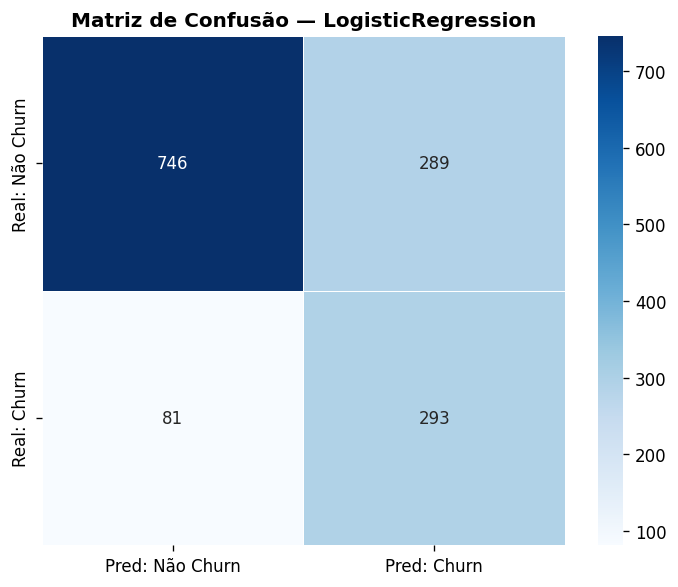

              precision    recall  f1-score   support

   Não Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [9]:
y_pred_lr = (y_prob_lr >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: Não Churn', 'Pred: Churn'],
            yticklabels=['Real: Não Churn', 'Real: Churn'], linewidths=0.5)
ax.set_title('Matriz de Confusão — LogisticRegression', fontweight='bold')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_lr, target_names=['Não Churn', 'Churn']))

---
## 5. Conclusões e Metas para Etapa 2

In [10]:
print('=' * 60)
print('           CONCLUSÕES — ETAPA 1')
print('=' * 60)
print(f'  DummyClassifier    → AUC-ROC: {results[0]["auc_roc"]:.4f} (piso)')
print(f'  LogisticRegression → AUC-ROC: {results[1]["auc_roc"]:.4f} | Recall: {results[1]["recall"]:.4f}')
print()
print('🎯 METAS PARA ETAPA 2 (MLP PyTorch):')
print(f'  • AUC-ROC > {results[1]["auc_roc"]:.4f}')
print('  • Recall  ≥ 0.70')
print('  • PR-AUC  ≥ 0.60')
print()
print('✅ Experimentos registrados no MLflow: churn-etapa1-baselines')
print('=' * 60)

           CONCLUSÕES — ETAPA 1
  DummyClassifier    → AUC-ROC: 0.5163 (piso)
  LogisticRegression → AUC-ROC: 0.8414 | Recall: 0.7834

🎯 METAS PARA ETAPA 2 (MLP PyTorch):
  • AUC-ROC > 0.8414
  • Recall  ≥ 0.70
  • PR-AUC  ≥ 0.60

✅ Experimentos registrados no MLflow: churn-etapa1-baselines


In [11]:
client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name('churn-etapa1-baselines')
runs = client.search_runs(exp.experiment_id, order_by=['metrics.auc_roc DESC'])
print(f'Runs registrados: {len(runs)}')
for run in runs:
    m = run.data.metrics
    name = run.data.tags.get('mlflow.runName', run.info.run_id)[:25]
    print(f'  {name:<25} | AUC-ROC: {m.get("auc_roc",0):.4f} | Recall: {m.get("recall",0):.4f}')

Runs registrados: 4
  LogisticRegression        | AUC-ROC: 0.8414 | Recall: 0.7834
  LogisticRegression        | AUC-ROC: 0.8414 | Recall: 0.7834
  DummyClassifier           | AUC-ROC: 0.5163 | Recall: 0.2914
  DummyClassifier           | AUC-ROC: 0.5163 | Recall: 0.2914
